In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import zipfile
from google.colab import files
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeUniform, GlorotUniform
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

Path

#Upload the Data

In [2]:
uploaded = files.upload()
with zipfile.ZipFile('Braintumer Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

Saving Braintumer Dataset.zip to Braintumer Dataset.zip


In [3]:
train_dir = '/content/Training'
test_dir = '/content/Testing'

In [4]:
filepaths_train= []
label_train = []
folds = os.listdir(train_dir)
for fold in folds:
    foldpath = os.path.join(train_dir,fold)
    files = os.listdir(foldpath)
    for file in tqdm(files):
        filepath = os.path.join(foldpath,file)
        filepaths_train.append(filepath)
        label_train.append(fold)

100%|██████████| 1339/1339 [00:00<00:00, 633307.74it/s]


In [5]:
len(filepaths_train)

5712

In [6]:
dftrain = pd.DataFrame({
'filepaths_train' : filepaths_train,
'label_train' : label_train
})

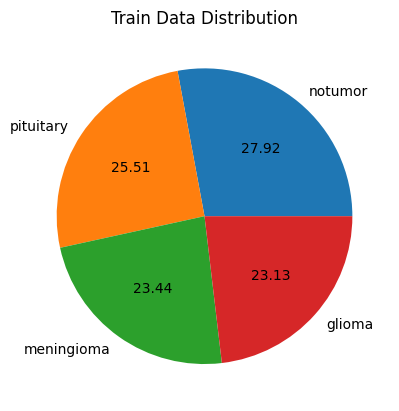

In [7]:
plt.pie(dftrain['label_train'].value_counts(),labels=dftrain['label_train'].value_counts().index,autopct='%.2f')
plt.title('Train Data Distribution')
plt.show()

In [8]:
dftrain.head()

,filepaths_train,label_train
0,/content/Training/pituitary/Tr-pi_0945.jpg,pituitary
1,/content/Training/pituitary/Tr-pi_0489.jpg,pituitary
2,/content/Training/pituitary/Tr-pi_1016.jpg,pituitary
3,/content/Training/pituitary/Tr-pi_1236.jpg,pituitary
4,/content/Training/pituitary/Tr-pi_0024.jpg,pituitary


In [9]:
dftrain['label_train'].value_counts()

,count
label_train,
notumor,1595
pituitary,1457
meningioma,1339
glioma,1321


#Read Test Data

In [10]:
filepaths_valid = []
label_valid = []
folds = os.listdir(test_dir)
for fold in folds:
    foldpath = os.path.join(test_dir, fold)
    files = os.listdir(foldpath)
    for file in tqdm(files):
        filepath = os.path.join(foldpath, file)
        filepaths_valid.append(filepath)
        label_valid.append(fold)

100%|██████████| 306/306 [00:00<00:00, 421358.18it/s]


In [11]:
len(filepaths_valid)

1311

In [12]:
df_valid = pd.DataFrame({
    'filepaths_valid': filepaths_valid,
    'label_valid': label_valid
})

In [13]:
df_valid.head()

,filepaths_valid,label_valid
0,/content/Testing/pituitary/Te-pi_0296.jpg,pituitary
1,/content/Testing/pituitary/Te-pi_0107.jpg,pituitary
2,/content/Testing/pituitary/Te-pi_0205.jpg,pituitary
3,/content/Testing/pituitary/Te-pi_0031.jpg,pituitary
4,/content/Testing/pituitary/Te-pi_0226.jpg,pituitary


In [14]:
df_valid['label_valid'].value_counts()

,count
label_valid,
notumor,405
meningioma,306
glioma,300
pituitary,300


#Train test split validation & test

In [15]:
filepaths_valid, filepaths_test, label_valid, label_test = train_test_split(
    df_valid['filepaths_valid'], df_valid['label_valid'], test_size=0.2, random_state=42, stratify=df_valid['label_valid']
)

In [16]:
df_test = pd.DataFrame({
    'filepaths_test': filepaths_test,
    'label_test': label_test
})

In [17]:
print("Validation set size:", len(filepaths_valid))
print("Test set size:", len(filepaths_test))
print("Validation labels size:", len(label_valid))
print("Test labels size:", len(label_test))


Validation set size: 1048
Test set size: 263
Validation labels size: 1048
Test labels size: 263


In [18]:
df_test.head()

,filepaths_test,label_test
488,/content/Testing/glioma/Te-gl_0299.jpg,glioma
916,/content/Testing/notumor/Te-no_0272.jpg,notumor
298,/content/Testing/pituitary/Te-pi_0048.jpg,pituitary
114,/content/Testing/pituitary/Te-pi_0159.jpg,pituitary
1251,/content/Testing/meningioma/Te-me_0243.jpg,meningioma


#Modeling

#Rescaling & Normalizing Images

In [19]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

Image Size & Batch Size

In [20]:
IMAGE_SIZE = (224,224)
batch_size = 32

#Class Distribution

# Image Processing & Augmentation

In [21]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

# Loads & Feeds Data to Model

In [22]:
train_gen = train_datagen.flow_from_dataframe(
    dftrain,
    x_col='filepaths_train',
    y_col='label_train',
    target_size=IMAGE_SIZE,
    shuffle=True,
    batch_size=batch_size
)

valid_gen = valid_datagen.flow_from_dataframe(
    df_valid,
    x_col='filepaths_valid',
    y_col='label_valid',
    target_size=IMAGE_SIZE,
    shuffle=False,
    batch_size=batch_size
)

test_gen = test_datagen.flow_from_dataframe(
    df_test,
    x_col='filepaths_test',
    y_col=None,
    target_size=IMAGE_SIZE,
    class_mode=None,
    shuffle=False,
    batch_size=batch_size
)

Found 5712 validated image filenames belonging to 4 classes.
Found 1311 validated image filenames belonging to 4 classes.
Found 263 validated image filenames.


In [23]:
print(f"Class Label :{train_gen.class_indices}")

Class Label :{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [24]:
list(train_gen.class_indices.keys())

['glioma', 'meningioma', 'notumor', 'pituitary']

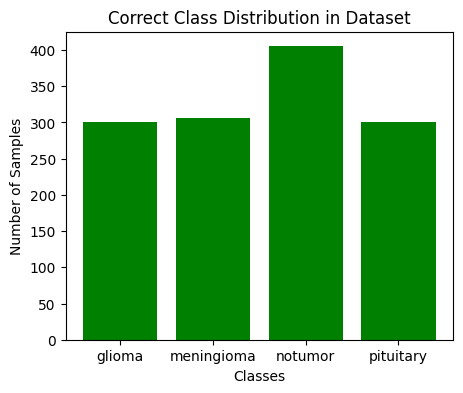

In [25]:
class_labels = list(valid_gen.class_indices.keys())
class_counts_dict = Counter(valid_gen.classes)
class_counts = [class_counts_dict[i] for i in range(len(class_labels))]


plt.figure(figsize=(5, 4))
plt.bar(class_labels, class_counts, color='green')
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Correct Class Distribution in Dataset")
plt.show()

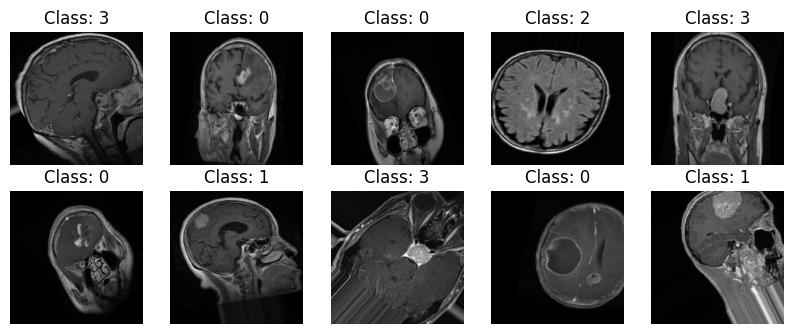

In [26]:
for batch_image, batch_label in train_gen:
    plt.figure(figsize=(10,10))
    for i in range (10):
        plt.subplot(5,5,i+1)
        plt.imshow(batch_image[i])
        plt.title(f"Class: {np.argmax(batch_label[i])}")
        plt.axis('off')
    break

#Using the MobileNet Model

In [27]:
base = MobileNet(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,524,676 (13.45 MB)

 Trainable params: 295,812 (1.13 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [28]:
model.compile(optimizer=Adam(learning_rate=0.0001) , loss="categorical_crossentropy", metrics=["accuracy"])

In [29]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

In [30]:
history = model.fit(
    train_gen,
    validation_data=(valid_gen),
    epochs=40,
    callbacks=[early_stopping, reduce_lr]
)


train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 90s 456ms/step - accuracy: 0.4750 - loss: 1.2733 - val_accuracy: 0.8063 - val_loss: 0.5361 - learning_rate: 1.0000e-04
Epoch 2/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 407ms/step - accuracy: 0.8095 - loss: 0.5376 - val_accuracy: 0.8116 - val_loss: 0.4701 - learning_rate: 1.0000e-04
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 72s 403ms/step - accuracy: 0.8419 - loss: 0.4350 - val_accuracy: 0.8757 - val_loss: 0.3602 - learning_rate: 1.0000e-04
Epoch 4/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 410ms/step - accuracy: 0.8593 - loss: 0.3880 - val_accuracy: 0.8696 - val_loss: 0.3560 - learning_rate: 1.0000e-04
Epoch 5/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 405ms/step - accuracy: 0.8773 - loss: 0.3323 - val_accuracy: 0.8719 - val_loss: 0.3305 - learning_rate: 1.0000e-04
Epoch 6/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 409ms/step - accuracy: 0.8930 - loss: 0.3072 - val_accuracy: 0.8986 - val_loss: 0.2841 - learning_rate: 1.0000e-04
Epoch 7/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 41

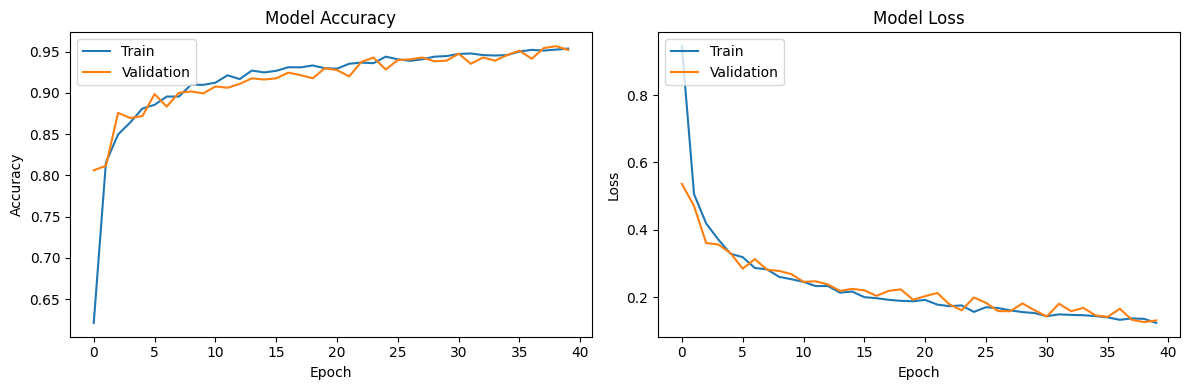

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

#Saving the model & making predictions

# Visualization the predictions by Confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step


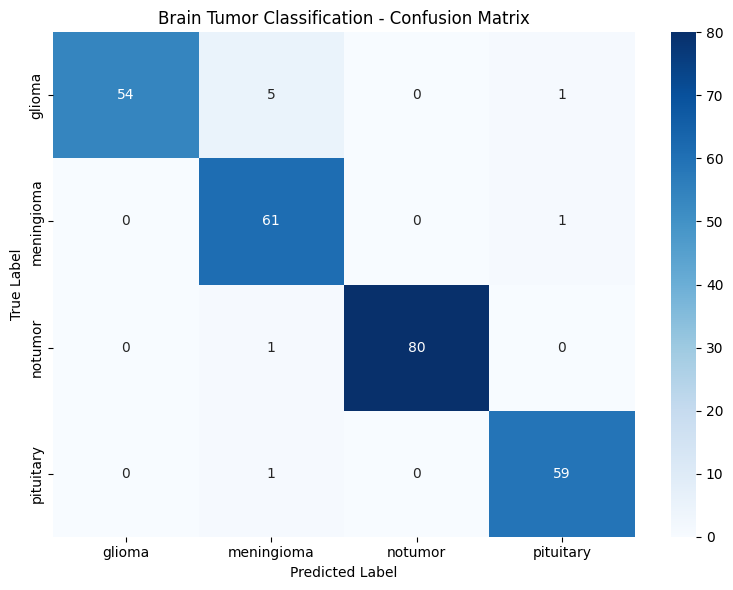

Classification Report:
               precision    recall  f1-score   support

      glioma       1.00      0.90      0.95        60
  meningioma       0.90      0.98      0.94        62
     notumor       1.00      0.99      0.99        81
   pituitary       0.97      0.98      0.98        60

    accuracy                           0.97       263
   macro avg       0.97      0.96      0.96       263
weighted avg       0.97      0.97      0.97       263



In [32]:
class_indices = {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
index_to_class = {v: k for k, v in class_indices.items()}
class_names = list(class_indices.keys())


y_true = np.array(label_test)
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

if isinstance(y_true[0], str):
    y_true = np.array([class_indices[label] for label in y_true])

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Brain Tumor Classification - Confusion Matrix")
plt.tight_layout()
plt.show()


print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

In [33]:
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f} ")

Test Set Accuracy: 0.9658 


In [35]:
model.save('Image_Detection_Model.h5')